### Exercise 8:


In [2]:
# importing the necessary python modules
# numpy and matplotlib are popular packages for scientific computing and plotting
import numpy as np
import matplotlib.pyplot as plt
import pygmsh
from matplotlib.animation import FuncAnimation

# interactive python (iPython) magic to instruct jupyter how to show the plots with respect to the code cells
%matplotlib inline

# various plotting parameters
plt.rcParams['text.usetex'] = False
plt.rcParams['axes.labelsize'] = 12

# scipy is an extension for numpy, used extensively in scientific computing
import scipy as sp

# The following lines are though to import the source functions
import sys
sys.path.append('../../src')

# And we import the necessary tools from our source folder.
from MesherWrapper import Mesh
from MeshUtils import MeshUtils
import MatrixAssembly
import PoroElasticProperties as prop

### The (sudden) excavation of a tunnel

This weeks exercise deals with a classical problem of geotechnical engineering. We will investigate the deformations and stresses induced by the (sudden) excavation of a tunnel. We will compare the undrained displacements and the drained stresses to analytical solutions. Mesh and material properties are provided. We use here quadratic interpolation for both displacement and pore-pressure.

### 1. Defining the mesh

We will begin by defining the mesh. As stated in the pdf it is sufficient to model a quarter of the domain only. Such reduction in domain calculations are only possible due to the symmetry of the problem, given by the assumption of constant stress and pore pressure fields in the beginning.

The total number of nodes in the mesh is 5008
The total number of elements in the mesh is 2403


Text(0, 0.5, 'y [m]')

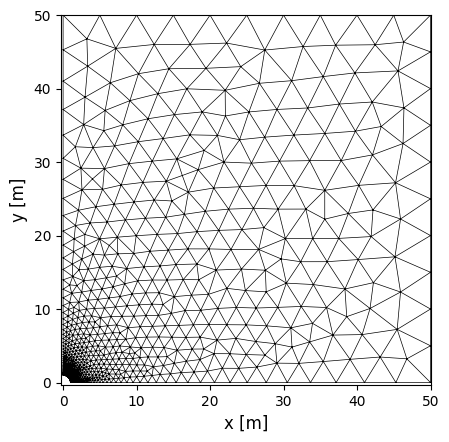

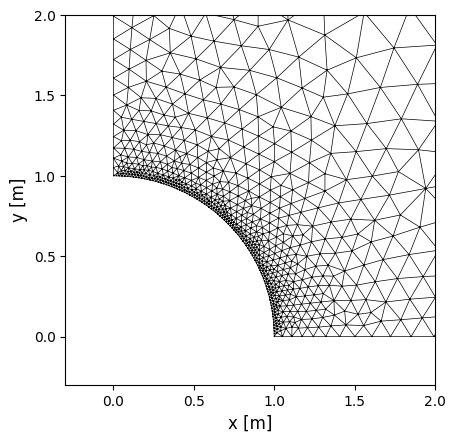

In [3]:
# We define the mesh with iths geometry
radius = 1                  # The radius of the tunnel
box_length = 50 * radius    # The size of the domain to be modelled
cell_size = 0.05           # the cell_size we want at the tunnel

# We want to ensure a sufficient discretization at the tunnel wall
ntheta = 90                                # number of increments on the quarter circle
theta = np.linspace(0, np.pi/2, ntheta)

vertices = np.flip(np.vstack((np.cos(theta), np.sin(theta))).T, axis = 0)      # vertices on the tunnel wall
other_vertices = np.array([[box_length, 0],
                            [box_length, box_length],
                            [0, box_length]])               # corners of the box
vertices = np.vstack((vertices, other_vertices))

# we define the cell size at the corners of the box and along the box
resolutions = 100 * cell_size * np.ones(len(vertices))
resolutions[:ntheta] = cell_size

# As always, we define a geometry for the mesh
with pygmsh.geo.Geometry() as geom:
    # we initiate an empty line list
    lines = []

    # we instantiate points p1 and p2 and make sure to store the first one in p0
    p1 = p0 = geom.add_point(vertices[0], resolutions[0])

    # at every iteration, we make a line going from p1 to p2
    for i in range(len(vertices) - 1):
        p2 = geom.add_point(vertices[i + 1], resolutions[i + 1])
        line = geom.add_line(p1, p2)
        lines.append(line)
        p1 = p2  # we make sure that p1 becomes p2, the next point to be in lines

    # we add the last line, closing the loop with p2 to p0
    lines.append(geom.add_line(p2, p0))

    # curve loop is a collection of lines where every endpoints are connected
    loop = geom.add_curve_loop(lines)  

    # the plane surface is the area that is going to be partitionned in finite elements
    surf = geom.add_plane_surface(loop)
    

    out = geom.generate_mesh()

# We can now generate our mesh.
mesh3 = Mesh(out, simultype='2D')

# Switching to the quadratic mesh as stated in the exo description
mesh = MeshUtils.tri3_to_tri6(mesh3)

# Printing out useful information
print(f'The total number of nodes in the mesh is {mesh.number_nodes}')
print(f'The total number of elements in the mesh is {mesh.number_els}')

# We can use the mesh.plot() visualize the mesh
fig, ax = mesh.plot()
ax.set_xlim(-0.3, box_length)
ax.set_ylim(-0.3, box_length)
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')

# We further show the settlements in z
fig, ax = mesh.plot()
ax.set_xlim(-0.3, 2 * radius)
ax.set_ylim(-0.3, 2 * radius)
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')

### 2. Boundary and initial conditions

We need to set the boundary conditions which are a mix of surface tractions (at the tunnel) and displacement conditions (on the outside of the box).

#### Displacement boundary conditions
The horizontal displacements will be fixed on the left boundary and the vertical displacements on the bottom boundary.

In [ ]:
# We get the boundaries needed to enforce boundary conditions
precision = cell_size * 1e-2 # we define a precision below the cell size to ensure we obtain the nodes as we introduced some numerical error
                             # on the tunnel wall.

# We give you the use of the precision as an example using the left boundary. 
left = np.argwhere(np.abs(mesh.nodes[:, 0] - mesh.nodes[:, 0].min()) <= precision)[:, 0]        # The left edge of the box
# Complete below for the other boundaries
# right =
# bottom =
# top = 
# tunnel =

fig, ax = mesh.plot()
# We visualize our choices of boundaries
for boundary in [left, right, bottom, top, tunnel]:
    plt.scatter(*mesh.nodes[boundary].T)
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')

# We further show the settlements in z
fig, ax = mesh.plot()
# We visualize our choices of boundaries
for boundary in [left, right, bottom, top, tunnel]:
    plt.scatter(*mesh.nodes[boundary].T)
ax.set_xlim(0.95 * radius, 1.05 * radius)
ax.set_ylim(-0.05 * radius, 0.1 * radius)
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')


In [ ]:
# we get the corresponding degree of freedom for the boundaries with no displacement
# complete below
# dof_left =                    # to limit displacements in x on the left
# dof_bottom =                  # to limit displacements in y on the bottom
nodes_fixed = np.unique(np.hstack((left, bottom)))
dof_fixed = np.unique(np.hstack((dof_left, dof_bottom)))

#### Setting the initial stress and pore pressure field
We prescribe an initial stress and pore pressure field of the problem.

In [ ]:
# we set the initial stress field (attention we keep everything in [MPa])
# complete below
# p0 =          # mean compressive stress [MPa]
# s0 =          # mean deviatoric stress [MPa]
stress_field = - np.array([p0 - s0, p0 + s0, 0])            # gives the three comoponents of the stress field
sigma = MatrixAssembly.set_stress_field(mesh, stress_field) # gives the values of the stresses at every node

# From the discrete stress field we get the force acting on the top and right faces
# complete below
# fx_right = 
# fy_top =

# We use these forces to assemble the force vector of the problem
fx = MatrixAssembly.assemble_tractions_over_line(mesh, right, [fx_right, 0])
fy = MatrixAssembly.assemble_tractions_over_line(mesh, top, [0, fy_top])
f = fx + fy - sigma

# we set the initial pore pressure field, it is zero on the tunnel's boundary
# complete below
# h0 =                  # defining the initial pore pressure [MPa]
# pore_pressure_free =  # indices of free pore pressure
# h =                   # initiate the solution vector
# h[...] = h0           # assemble the solution

# We print the shape of the stress-field vectorprint(f'The shape of the stress field is {sigma.reshape(2, -1, order='F').shape}')
print(sigma.reshape(2, -1, order='F').shape)

# We sow the stress-field
fig, ax, cb = mesh.plot(sigma.reshape(2, -1, order='F')[0])
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
cb.ax.set_title('sigma_xx [MPa]')

### 3. Defining all material parameters

We stick to the definition of everything in [MPa].

In [ ]:
# geomechanical parameters
k = 8.4e3           # elastic drained bulk modulus MPa]
g = 6.8e3           # shear modulus [MPa]
b = 0.707692        # biot coefficient
M = 9.18478e3       # biot modulus [MPa]
perm = 0.137549e-3  # permeability

# We can now calculate the undrained bulk modulus
k_u = prop.undrained_bulk_modulus(k, b, M)

# We define the skempton coefficient
B = (k_u-k)/(b*k_u)

# And we define the properties of the fluid
mu_f = 1            # fluid viscosity
rho = 1             # density
kappa = perm/mu_f   # conductivity

# We can now calculate the remaining undrained and drained properties and the coefficient eta
nu_u = prop.poisson_ratio(g, k_u)   # undrained poisson ratio
E_u = prop.young_modulus(g, k_u)    # undrained yougn modulus
nu = prop.poisson_ratio(g, k)       # poisson ratio
E = prop.young_modulus(g, k)        # young modulus
eta = b*(1-2*nu_u)/(2*(1-nu_u))     # poroelastic parameter

### 4. We can now start assembling the system

To this end, we calculate all necessary matrices to finally assembly the entire syxstem.

In [ ]:
# we build the necessary matrix for the equilibrium test
K = MatrixAssembly.assemble_stiffness_matrix(mesh, E, nu)

#### 4.1 Equilibrium test

The calculation of the resulting forces on the faces was necessary to ensure that we do have no displacements under the initial conditions. We test if this is well the case here to ensure that our implementation is correct.

In [ ]:
# we can test the system to see if there's any displacement in equilibrium
# To be fully in equilibrium, we slightly have to adapt the force vector as we consider
# that the excavation has not yet happened. So we compensat for this fact imposing
# the equivalent stresses at the tunnel wall (second part of following equation).
# complete below
# f_test =

# the free DOFs
# complete below
# to_solve =

# solving the elastic problem
# complete below
# to_solve =

# preparing the solution vector
u = np.zeros(2 * mesh.number_nodes)

# combining the solution
# complete below
# u[...] =

# we print the maximum displacement
print(f'Maximum displacement should be quite small: {np.abs(u_solved).max():.2e} [mm]')

# and show the norm of the dipslacements
fig, ax, cb = mesh.plot(np.linalg.norm(u.reshape(2, -1, order='F'), axis=0), shading='flat')
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
cb.ax.set_title('norm of the displacement |u| [mm]')

#### 4.2 Undrained solution

In the first step we now calculate the solution to the undrained problem. This will give us the initial part of the traind problem.

First we will have to get the matrices.

Note that you have to code up a part of the coupling matrix assembly to make this work. Go to `src/Elements.py` and code up the function `element_coupling_matrix()`.

In [ ]:
# assembling the matrices.
# Note that you have to code up a part of the coupling
# matrix assembly to make this work. 
S = MatrixAssembly.assemble_mass_matrix(mesh, 1/M)
C = MatrixAssembly.assemble_conductivity_matrix(mesh, kappa)
Ce = MatrixAssembly.assemble_coupling_matrix(mesh, b)

In [ ]:
# we can solve for the undrained solution, defining the single large matrix
dt = 0

# Get the bottom right part of the matrix
AA = S + dt * C

# Getting all the relevant parts of the problem
ntot_E = mesh.number_nodes * 2
ntot_P = mesh.number_nodes
ntot = ntot_E + ntot_P


# assembling the full matrix
# complete the code below
# top_ma = sp.sparse.hstack((..., ...), format='csc')
# bottom_ma = sp.sparse.hstack((..., ...), format='csc')
T = sp.sparse.vstack((top_ma, bottom_ma), format='csc')

# We index the parts of the problem we want to get the solution to.
# complete the code below
# displacement_free =
# eq_free =
# eq_fixed =

# we need to set the force vector to the initial conditions, accounting to pore pressure
ftot = np.zeros(ntot)
# complete the code below
# ftot =

# we solve the system
sol_undrained = np.zeros(ntot)
sol_undrained[eq_free] = sp.sparse.linalg.spsolve(T[eq_free][:, eq_free], ftot[eq_free])

# we can separate the solution in both displacement and pore pressure
displacement_undrained = sol_undrained[:ntot_E].reshape(2, -1, order='F')
pore_pressure_undrained = sol_undrained[ntot_E:]

# We visualize the result
fig, ax, cb = mesh.plot(np.linalg.norm(displacement_undrained, axis=0), c='none')
ax.triplot(*(mesh.nodes.T + 100 * displacement_undrained), mesh.connectivity[:, :3], c='red', zorder=10, lw=1)
ax.set_xlim(-0.5, 3)
ax.set_ylim(-0.5, 3)
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_title('vertical disp. (100x exaggeration)')
cb.ax.set_title('norm of the displacement |u| [mm]')

##### 4.2.1 Compare the drained solution to analytical solution

We choose to visualize the solution at the top point of symmetry on the tunnel wall (at the top and at the right end).

The analytical displacement at the top is given by 

$u_{r}(r=r_{o},\theta=90°,t=0^{+})=-\frac{P_{o}r_{o}}{2G}-\frac{(3-4\nu_{u})r_{o}S_{o}}{2G}$.

Another value to compare is the pressure along the axis $x = -d_{area}$

$p(r,\theta=0\text{°},t=0^{+})=\frac{4B(1+\nu_{u})}{3}\frac{r_{o}^{2}}{r^{2}}S_{o}+p_{o}$

In [ ]:
# We first define the function giving the analytical solution for displacement.
# complete the code below
# u_r_analytical =

# Function to get the pressure along the baseline
# complete the code below
# def pressure_along_x_axis(....):
#     return ...

We now get the point on top and bottom, and we compare the displacement.

In [ ]:
# by extracting the values at a node we can compare the two.
# complete the code below
# top_point = 

# Printing settlements and error
print(f'The numerical displacement is given by: {displacement_undrained[1, top_point]} [mm]')
print(f'The theoretical displacement is given by: {u_r_analytical} [mm]')
print(f'The relative error between the two is: {abs((u_r_analytical - displacement_undrained[1, top_point]) / u_r_analytical) * 100} %')


And compare now the pressure.

In [ ]:
# lets first order the elements on top for plotting regions
indices = np.argsort(mesh.nodes[bottom, 0])
bottom = bottom[indices]
# First define the analytical solution
# complete the code below
# p_undrained_x_analytical =

# and we get the numerical pressure
# p_undrained_x_numerical =

# We plot the lines to compare the analytical and theoretical solution on the top surface.
plt.figure(1)
plt.plot(mesh.nodes[bottom, 0], p_undrained_x_analytical, 'r--')
plt.scatter(mesh.nodes[bottom, 0], p_undrained_x_numerical)
plt.ylabel('p [MPa]')
plt.xlabel('x-coordinate at bottom [m]')

# It is of course more interesting to see the error.
# we scale by the analytical solution at the tunnel wall x = r0
scaled_absolute_error = abs((pressure_along_x_axis(B, nu_u, radius, s0, h0, mesh.nodes[bottom, 0]) - p_undrained_x_numerical)) / pressure_along_x_axis(B, nu_u, radius, s0, h0, radius)

# We plot the lines to compare the analytical and theoretical solution on the top surface.
plt.figure(2)
plt.scatter(mesh.nodes[bottom, 0], scaled_absolute_error)
plt.yscale('log')
plt.ylabel('scaled absolute error on p')
plt.xlabel('x-coordinate at bottom [m]')

#### 4.3 Drained solution

We want to get the temporal evolution in time. As such we try to get the solution to the problem on a logspaced time-grid.

In [ ]:
# we want to compute the time varying solution on log-spaced time intervals
t = np.logspace(-5, 2, 100)
# complete the code below
# dt =

# we prepare the solution vectors
solutions = np.zeros((len(t), ntot))
solutions[0] = sol_undrained

# we need to set the force vector
ftot = np.zeros(ntot)

# This is the time integration loop.
for i, dt_i in enumerate(dt):
    print(f'\riteration {i + 1} out of {len(dt)}', end='\n')

    # update the corresponding part of the full matrix
    # complete the code below:
    # bottom_ma =
    # T =
  
    # the change in flux is adjusted
    flux = dt_i * C[pore_pressure_free].dot(solutions[i, ntot_E:])
    ftot[pore_pressure_free + ntot_E] = flux

    # solve the system
    update = sp.sparse.linalg.spsolve(T[eq_free][:, eq_free], ftot[eq_free])
    solutions[i + 1, eq_free] = solutions[i, eq_free] + update

# we can separate the displacements from the pore pressure to look at it
displacement_field = solutions[:, :ntot_E].reshape(len(t), 2, -1, order='F')
pore_pressure_field = solutions[:, ntot_E:]


#### 4.3.1 Comparing the displacement in time

 As to check the solution we will plot the evolution of the displacement of the top node and compare to the early time solution (given by the equation above) and the large time solution easily calculated by simply replacing $\nu_{u}$ with $\nu$ in said equation.

In [ ]:
# We first define the function giving the analytical solution for displacement at late time.
# complete the code below
# u_r_analytical_late_time =

# Printing settlements and error
print(f'The numerical displacement is given by: {displacement_field[-1, 1, top_point]} [mm]')
print(f'The theoretical displacement is given by: {u_r_analytical_late_time} [mm]')
print(f'The relative error between the two is: {abs((u_r_analytical_late_time - displacement_field[-1, 1, top_point]) / u_r_analytical_late_time) * 100} %')

# lets see where the two points are
mesh.plot()
plt.figure(1)
plt.scatter(*mesh.nodes[top_point].T)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.xlim(-0.5, 3)
plt.ylim(-0.5, 3)

# visualizing the temporal evolution of the displacements
plt.figure(2)
plt.plot(t, displacement_field[:, 1, top_point], label='top, vertical displacement')
plt.plot(t, np.ones(len(t)) * u_r_analytical, label='top, undrained disp')
plt.plot(t, np.ones(len(t)) * u_r_analytical_late_time, label='top, late time drained disp')
plt.legend(frameon=False)
plt.xlabel('time (s)')
plt.ylabel('disp. (m)')
plt.xscale('log')
plt.xlim(t[0], t[-1])

#### 4.3.2 Comparing the stresses

Finally, we will compare the stresses along the axis $x=-d_{area}$ with the analytical solution given by:

$\sigma_{xx}(r)=-P_{o}\left(1-\frac{r_{o}^{2}}{r^{2}}\right)+S_{o}\left(1-4\frac{r_{o}^{2}}{r^{2}}+3\frac{r_{o}^{4}}{r^{4}}\right)+\eta p_{o}\left(1-\frac{r_{o}^{2}}{r^{2}}\right)$

defining first the analytical solution.

In [ ]:
# We first define the function giving the analytical solution
# Complete below
# def stresses_along_x_axis(...):

We now calculate the stresses

In [ ]:
# We calculate the different comoponents of the stresses
# complete the code below
# .... = MatrixAssembly.project_stress(...)

and compare now the solutions,

In [ ]:
# We get the analytical stresses centrally below the foundation
# complete the code below
# sigma_xx-analytical = ...

# We plot the lines to compare the analytical and theoretical solution on the top surface.
plt.figure(1)
plt.plot( mesh.nodes[bottom, 0], sigma_xx_analytical, 'r--')
plt.scatter(mesh.nodes[bottom, 0], sigma_xx[bottom])
plt.ylabel('Evolution of sigma_xx drained status')
plt.xlabel('x-coordinate at bottom [m]')

# It is of course more interesting to see the error.
# we scale by the analytical solution at a distance r from the tunnel
scaled_absolute_error = abs((sigma_xx_analytical - sigma_xx[bottom]) / stresses_along_x_axis(p0, radius, s0, eta, h0, 2 * radius))

# We plot the lines to compare the analytical and theoretical solution on the top surface.
plt.figure(2)
plt.scatter(mesh.nodes[bottom, 0], scaled_absolute_error)
plt.yscale('log')
plt.ylabel('scaled absolute error on sigma_xx')
plt.xlabel('x-coordinate at bottom [m]')

We also plot the evolution of pore pressure in the domain with time.

In [ ]:
# Get the information on the pore pressure field.
mean = pore_pressure_field.mean(axis=-1)
std = pore_pressure_field.std(axis=-1)
max = pore_pressure_field.max(axis=-1)
min = pore_pressure_field.min(axis=-1)

# and we plot the values with a shading
plt.plot(t, mean)
plt.fill_between(t, mean - std, mean + std, alpha=0.3)
plt.fill_between(t, min, max, alpha=0.2, fc='tab:blue')
plt.legend(frameon=False)
plt.xlabel('time (s)')
plt.ylabel('head distribution (m)')
plt.xscale('log')
plt.xlim(t[0], t[-1])

Now let us animate the evolution of the pore pressure in the entire field.

In [ ]:
# We change the plotting to have an animation
%matplotlib qt 

# maximum value of the pore pressure within the field
vmax = np.abs(pore_pressure_field).max()

# setting up the figure
fig = plt.figure()
ax = fig.add_subplot()
# cb = fig.colorbar()
im = ax.tripcolor(*mesh.nodes.T, mesh.connectivity[:, :3], pore_pressure_field[0], lw=1, shading='gouraud',
                  vmin=-vmax, vmax=vmax, cmap='RdBu')
time = ax.set_title('t=0')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
plt.colorbar(im)
ax.set_aspect(1)
mesh.plot(ax=ax)

def update(i):
    time.set_text(f'maximum pore pressure per element at t={t[i]:.2f}')
    im.set_array(pore_pressure_field[i])
    return im, time

# Animate the figure
ani = FuncAnimation(fig, update, frames=len(t), interval=100)


Now let us animate the evolution of the displacement in the entire field.

In [ ]:
# We change the plotting to have an animation
%matplotlib qt

# get the norm of the displacement
disp = np.linalg.norm(displacement_field, axis=1)

# Now get the figure
fig = plt.figure()
ax = fig.add_subplot()
im = ax.tripcolor(*mesh.nodes.T, mesh.connectivity[:, :3], disp[0], lw=1, shading='gouraud')
time = ax.set_title('t=0')
plt.colorbar(im)

def update(i):
    time.set_text(f'norm of displacement at t={t[i]:.2f}')
    im.set_array(disp[i])
    return im, time

# Animate the figure
ani = FuncAnimation(fig, update, frames=len(t), interval=100)

Just to ensure that we get the inline plotting again.

In [ ]:
# interactive python (iPython) magic to instruct jupyter how to show the plots with respect to the code cells
%matplotlib inline